In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [4]:
def K(x,a): #x pos a spin
    return (x[0]**2+x[1]**2+x[2]**2-a**2)/2

def W(x,a):
    return np.sqrt(K(x,a)**2+a**2*x[2]**2)

def derivW(x,a):
    k=K(x,a)
    w=W(x,a)

    DxW=k*x[0]/w
    DyW=k*x[1]/w
    DzW=x[2]*(k+a**2)/w

    DW=np.array([DxW,DyW,DzW])
    return DW

def R(x):
    return np.sqrt(x[0]**2+x[1]**2+x[2]**2)

def derivr(x,a):
    w=W(x,a)
    r=R(x)
    
    Dxr=x[0]*r/(2*w)
    Dyr=x[1]*r/(2*w)
    Dzr=x[2]*(r**2+a**2)/(2*r*w)

    Dr=np.array([Dxr,Dyr,Dzr])
    return Dr

def derivS(x,a):
    w=W(x,a)
    r=R(x)

    DxS=2*x[0]*r**4/w
    DyS=2*x[1]*r**4/w
    DzS=2*r**2*(r**2+a**2)*x[2]/w+2*a**2*x[2]

    DS=np.array([DxS,DyS,DzS])
    return Ds

def F(x,a, M):
    r=R(x)
    w=W(x,a)
    return M*r/w

def derivf(x,a,M): #M_BH
    w=W(x,a)
    r=R(x)

    Df=M/w*(derivr(x,a)-r/w*derivW(x,a))
    return Df

def LL(x,a):
    r=R(x)
    
    Lx=(x[0]*(a**2-r**2)-2*a*r*x[1])/(r**2+a**2)**2
    Ly=(x[1]*(a**2-r**2)+2*a*r*x[0])/(r**2+a**2)**2
    Lz=-x[2]/r**2

    L=np.array([Lx,Ly,Lz])
    return L

def ll(x,a):
    r=R(x)

    lt=1
    lx=(r*x[0]+a*x[1])/(r**2+a**2)
    ly=(r*x[1]-a*x[0])/(r**2+a**2)
    lz=x[2]/r

    l=np.array([lt,lx,ly,lz])
    return l

def delta(i,j):
    if i==j:
        return 1.0
    else:
        return 0.0

def derivl(x,a):
    r=R(x)
    L=LL(x,a)
    Dr=derivr(x,a)

    Dlt=np.zeros(3)
    Dlx=np.zeros(3)
    Dly=np.zeros(3)
    Dlz=np.zeros(3)
    
    for i in range(3):
        Dlx[i]=(r*delta(i,0)+a*delta(i,1))/(r**2+a**2)+L[0]*Dr[i]
        Dly[i]=(r*delta(i,1)-a*delta(i,0))/(r**2+a**2)+L[1]*Dr[i]
        Dlz[i]=delta(i,2)/r+L[2]*Dr[i]
    
    Dl=np.array([Dlt,Dlx,Dly,Dlz])
    Dl_transp=np.transpose(Dl)
    return Dl_transp

def derivg(x,a,M):
    Df=derivf(x,a,M) #3
    f=F(x,a,M) #1
    l=ll(x,a) #4
    Dl=derivl(x,a) #3x4
    
    Dg=np.zeros((3,4,4))
    for k in range(3):
        for mu in range(4):
            for nu in range(4):
                Dg[k,mu,nu]=Df[k]*l[mu]*l[nu]+f*Dl[k,mu]*l[nu]+f*l[mu]*Dl[k,nu]

    return Dg

def derivg4(x,a,M):
    Df=derivf(x,a,M) #3
    f=F(x,a,M) #1
    l=ll(x,a) #4
    Dl=derivl(x,a) #3x4
    
    Dg=np.zeros((4,4,4))
    for k in range(3):
        for mu in range(4):
            for nu in range(4):
                Dg[k+1,mu,nu]=Df[k]*l[mu]*l[nu]+f*Dl[k,mu]*l[nu]+f*l[mu]*Dl[k,nu]

    return Dg

def GG(x,a,M):
    l=ll(x,a)
    l[0]=-l[0]
    Dg=derivg4(x,a,M)

    G=np.zeros((4,4))
    for alpha in range(4):
        for beta in range(4):
            G[alpha,beta]=np.sum(l[:]*(Dg[alpha,beta,:]+Dg[beta,alpha,:]-Dg[:,alpha,beta]))

    return G

def Gamma_bar(x,a,M):
    Dg=derivg4(x,a,M)
    Gamma=np.zeros((4,4,4))
    for alpha in range(4):
        for beta in range(4):
            for mu in range(4):
                Gamma[mu][alpha][beta]=np.sum(0.5*np.diag([-1,1,1,1])[mu,:]*(Dg[alpha,:,beta]+Dg[beta,alpha,:]-Dg[:,alpha,beta]))

    return Gamma

def FF(x,v,a,M):
    Gamma=Gamma_bar(x,a,M)
    vt=np.array([1.])
    v4=np.append(vt,v)
    
    F=np.zeros(3)
    for i in range(3):
        for alpha in range(4):
            F[i]=F[i]+np.sum(-Gamma[1+i,alpha,:]*v4[alpha]*v4[:]+Gamma[0,alpha,:]*v4[alpha]*v4[:]*v[i])

    return F

def dv(x,v,a,M):
    Gab=GG(x,a,M)
    f=F(x,a,M)
    FFF=FF(x,v,a,M)
    l=ll(x,a)
    vt=np.array([1.])
    v4=np.append(vt,v)

    G=0
    for alpha in range(4):
        G=G+np.sum(Gab[alpha][:]*v4[alpha]*v4[:])

    l3d=l[1:]
    
    acc=FFF+f/2*G*(l3d+v)

    return acc

def funz(t,y,a,M):
    #a,M=args
    x1,x2,x3,v1,v2,v3 = y
    x=np.array([x1,x2,x3])
    v=np.array([v1,v2,v3])

    acc=dv(x,v,a,M)

    #print(v1,v2,v3,acc[0],a[1],a[2],a,M)
    ynew=np.array([v1,v2,v3,acc[0],acc[1],acc[2]])
    #print(t)

    return ynew    

In [5]:
x=np.array([50,0,0])
v=np.array([0,0.14142136,0])
G=1
M=1
a=0
e=0.0
p=50*M
P=2*np.pi*np.sqrt(R(x)**3/(G*M))
tf=10*P
y0=np.array([x[0],x[1],x[2],v[0],v[1],v[2]])

t_span=[0,tf]
t_ev=np.linspace(0,tf,1000)

sol=scipy.integrate.solve_ivp(funz,t_span,y0, method='DOP853',t_eval=t_ev,rtol=1e-11,atol=1e-13,args=np.array([a,M]))

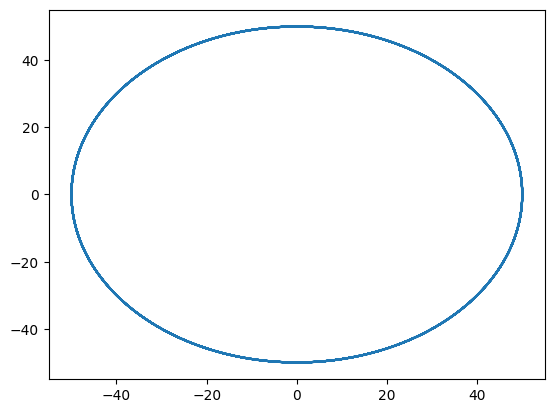

In [6]:
y=sol['y']

plt.plot(y[0],y[1])


In [7]:
#print(sol['t'])

In [8]:
FF(x,v,a,M)

array([-4.16000001e-04, -2.26274188e-06,  0.00000000e+00])

In [9]:
Gamma=Gamma_bar(x,a,M)
vt=np.array([0.])
v4=np.append(vt,v)

print(Gamma[0,:,:]*v4[:]*v4[:])

print(np.sum(Gamma[0,:,:]*v4[:]*v4[:]))

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -1.60000009e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00]]
-1.600000085139968e-05


In [10]:
Gamma_bar(x,a,M)

array([[[ 0.    ,  0.0004,  0.    ,  0.    ],
        [ 0.0004,  0.0008,  0.    ,  0.    ],
        [ 0.    ,  0.    , -0.0008,  0.    ],
        [ 0.    ,  0.    ,  0.    , -0.0008]],

       [[ 0.0004,  0.    ,  0.    ,  0.    ],
        [ 0.    , -0.0004,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.0008,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.0008]],

       [[ 0.    ,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.    ]],

       [[ 0.    ,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    ,  0.    ]]])

In [11]:
vt=np.array([1.])
v4=np.append(vt,v)

Gamma_bar(x,a,M)[0,1,0]*v4[1]*v4[0]

np.float64(0.0)

In [12]:
l=ll(x,a)
print(l)
l3d=l[1:]
print(l3d)

[1. 1. 0. 0.]
[1. 0. 0.]


In [52]:
e = 0.5
a = 0.
sma = 50
p = sma * (1-e**2)


rapo = p/(1-e)
rperi = p/(1+e)

In [53]:
def E(p=p,e=e):
    return np.sqrt((p-2-2*e)*(p-2+2*e)/(p*(p-3-e**2)))
def L_z(p=p,e=e):
    return p/np.sqrt(p-3-e**2)
def Q(L_x,L_y,p=p,e=e):
    return L_x**2 + L_y**2

Q = Q(0,0)
Q

0

In [66]:
def rtp_prime(t,y,args=None):
    #a, M, p, e = args
    t,r,theta,phi = y[0],y[1],y[2],y[3]
    #u = np.array([y[3],y[4],y[5]])
    
    E = np.sqrt((p-2-2*e)*(p-2+2*e)/(p*(p-3-e**2)))
    #print(E)
    Lz = p/np.sqrt(p-3-e**2)
    #print(Lz)
    
    Delta = r**2-2*M*r+a**2
    #print(Delta)
    Sigma = r**2+a*2*np.cos(theta)**2
    #print(Sigma)

    R = (E*(r**2+a**2)-a*Lz)**2 - Delta*(r**2+(Lz-a*E)**2+Q)
    #print(R)
    Theta = Q - np.cos(theta)**2*(a**2*(1-E**2)+Lz**2/np.sin(theta)**2)
    if abs(np.cos(theta))<1e-16: Theta = 0
    #print(Theta)


    
    t_prime = ((r**2+a**2)*(E*(r**2+a**2)-a*Lz)/Delta - a*(a*E*np.sin(theta)**2-Lz)) / Sigma
    #print(t_prime)

    phi_prime = (a*(E*(r**2+a**2)-a*Lz)/Delta - (a*E-Lz/np.sin(theta)**2)) / Sigma
    #print(phi_prime)

    r_prime = np.sqrt(R)/Sigma
    if (r==rapo or r==rperi): r_prime=0
    #print(r_prime)

    theta_prime = np.sqrt(Theta)/Sigma
    #print(theta_prime)

    
    return np.array([t,r,theta,phi, t_prime,r_prime,theta_prime,phi_prime])

In [67]:
y0 = rtp_prime(0,[0,rapo, np.pi/2, 0, 1, 0, 0, 1e3])
y0

C:\Users\insta\AppData\Local\Temp\ipykernel_32636\4193752292.py:30: RuntimeWarning: invalid value encountered in sqrt
  r_prime = np.sqrt(R)/Sigma


array([0.00000000e+00, 7.50000000e+01, 1.57079633e+00, 0.00000000e+00,
       1.01729863e+00, 0.00000000e+00, 0.00000000e+00, 1.13914354e-03])

In [70]:
v_BL = y0[4:]/y0[4]
#v_BL=np.append(1,v_BL)
print(v_BL)

[1.         0.         0.         0.00111977]


In [71]:
y0_BL = np.append(y0[:3],v_BL)
y0_BL
t,r_BL,theta_BL,phi_BL = y0[:4]

In [72]:
x = np.sqrt(r_BL**2+a**2)*np.sin(theta_BL)*np.cos(phi_BL)
y = np.sqrt(r_BL**2+a**2)*np.sin(theta_BL)*np.sin(phi_BL)
z = r_BL*np.cos(theta_BL)

Delta = r_BL**2-2*M*r_BL+a**2
phi_=phi_BL+np.arctan(a/r_BL)
rho=np.sqrt(r_BL**2 +a**2)

dx_dr=(r_BL*np.cos(phi_)+a*np.sin(phi_))*np.sin(theta_BL)/rho
dy_dr=(r_BL*np.sin(phi_)-a*np.cos(phi_))*np.sin(theta_BL)/rho
dz_dr=np.cos(theta_BL)

dx_dtheta= rho*np.cos(theta_BL)*np.cos(phi_)
dy_dtheta= rho*np.cos(theta_BL)*np.sin(phi_)
dz_dtheta= -r_BL*np.sin(theta_BL)

dx_dphi= -rho*np.sin(theta_BL)*np.sin(phi_)
dy_dphi= rho*np.sin(theta_BL)*np.cos(phi_)
dz_dphi= 0.0

J = np.array([[1, 2*M*r_BL/Delta, 0, 0], [0, dx_dr, dx_dtheta, dx_dphi], [0, dy_dr, dy_dtheta, dy_dphi], [0, dz_dr, dz_dtheta, dz_dphi]])

print(J)

[[ 1.00000000e+00  2.73972603e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  4.59242550e-15 -0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  7.50000000e+01]
 [ 0.00000000e+00  6.12323400e-17 -7.50000000e+01  0.00000000e+00]]


In [80]:
v_KS=np.zeros(4)

for i in range(4):
    for alpha in range(4):
        v_KS[i]=v_KS[i]+np.sum(J[i,alpha]*v_BL[alpha] / (1+2*M*r_BL/Delta *v_BL[1]))

v_KS

array([1.        , 0.        , 0.08398298, 0.        ])

In [81]:
X_KS=np.array([x,y,z])

In [82]:
def metric(x,a,M):
    eta=np.diag([-1,1,1,1])
    r=R(x)
    l=ll(x,a)

    g=np.zeros((4,4))
    for mu in range(4):
        for nu in range(4):
            g[mu,nu]=eta[mu,nu]-2*M*r**3/(r**4+a**2*z**2)*l[mu]*l[nu]

    return g

In [83]:
gmunu=metric(X_KS,a,M)
gmunu

array([[-1.02666667e+00, -2.66666667e-02,  0.00000000e+00,
        -1.63286240e-18],
       [-2.66666667e-02,  9.73333333e-01,  0.00000000e+00,
        -1.63286240e-18],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [-1.63286240e-18, -1.63286240e-18,  0.00000000e+00,
         1.00000000e+00]])

In [84]:
def t0_dot_func(x,a,M,v):
    gmunu=metric(x,a,M)
    t0_dot=0
    for mu in range(4):
        for nu in range(4):
            t0_dot=t0_dot + 1/np.sqrt(gmunu[mu,nu]*v[mu]*v[nu])

    return t0_dot

In [85]:
#v4_KS=np.append(1.,v_KS)

t0_dot=t0_dot_func(X_KS,a,M,v_KS)
t0_dot

C:\Users\insta\AppData\Local\Temp\ipykernel_32636\3745530098.py:6: RuntimeWarning: invalid value encountered in sqrt
  t0_dot=t0_dot + 1/np.sqrt(gmunu[mu,nu]*v[mu]*v[nu])
C:\Users\insta\AppData\Local\Temp\ipykernel_32636\3745530098.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  t0_dot=t0_dot + 1/np.sqrt(gmunu[mu,nu]*v[mu]*v[nu])


np.float64(nan)